# Импорты, пути, данные

## Импорты

In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl

import lightgbm as lgb
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import roc_auc_score

import joblib

import os

import numpy as np
from pathlib import Path

## Пути

In [2]:
path_train = "data\\train\\"
path_test = "data\\test\\"
path_sample_submit = "data\\sample_submit.parquet"
path_summit = "data\\submission\\"

path_save_model_all_feature = "data\model\model_baseline_all_feature\\"
path_save_model_part_feature = "data\model\model_baseline_part_feature\\"
path_save_model_minimum_feature = "data\model\model_minimum_feature\\"
path_save_model_with_extra_feature = "data\model\model_extra_feature\\"
path_save_model_with_extra_feature2 = "data\model\model_extra_feature2\\"

## Загрузка и обработка данных

### Загрузка данных

In [3]:
train_m = pd.read_parquet(f"{path_train}train_main_features.parquet")
train_e = pd.read_parquet(f"{path_train}train_extra_features.parquet")
train_t = pd.read_parquet(f"{path_train}train_target.parquet")

In [4]:
train = train_m.merge(train_e, on="customer_id", how="left")


In [5]:
# test_m = pd.read_parquet(f"{path_test}test_main_features.parquet")
# test_e = pd.read_parquet(f"{path_test}test_extra_features.parquet")

### Столбцы для удаления

In [6]:
drop_features1 = list(train.isnull().sum().sort_values(ascending=False)[:600].index)

In [7]:
drop_features2 = ['num_feature_559',
 'num_feature_563',
 'num_feature_568',
 'num_feature_573',
 'num_feature_1809',
 'num_feature_541',
 'num_feature_373',
 'num_feature_2065',
 'num_feature_973',
 'num_feature_992',
 'num_feature_980',
 'num_feature_556',
 'num_feature_1804',
 'num_feature_1799',
 'num_feature_2032',
 'num_feature_1989',
 'num_feature_350',
 'num_feature_416',
 'num_feature_346',
 'num_feature_336',
 'num_feature_1737',
 'num_feature_1006',
 'num_feature_2103',
 'num_feature_1739',
 'num_feature_2101',
 'num_feature_1727',
 'num_feature_2095',
 'num_feature_1746',
 'num_feature_388',
 'num_feature_378',
 'num_feature_1791',
 'num_feature_397',
 'num_feature_1035',
 'num_feature_1081',
 'num_feature_2113',
 'num_feature_2339',
 'num_feature_1461',
 'num_feature_1453',
 'num_feature_1465',
 'num_feature_1466',
 'num_feature_2311',
 'num_feature_2315',
 'num_feature_2329',
 'num_feature_1937',
 'num_feature_695',
 'num_feature_510',
 'num_feature_496',
 'num_feature_700',
 'num_feature_1767',
 'num_feature_1769',
 'num_feature_1773',
 'num_feature_2051',
 'num_feature_2056',
 'num_feature_2033',
 'num_feature_455',
 'num_feature_2049',
 'num_feature_519',
 'num_feature_1996',
 'num_feature_432',
 'num_feature_2367',
 'cat_feature_17',
 'cat_feature_28',
 'num_feature_1442',
 'num_feature_2360',
 'num_feature_308',
 'num_feature_2132',
 'num_feature_2133',
 'num_feature_1644',
 'num_feature_1657',
 'num_feature_1646',
 'num_feature_1138',
 'num_feature_1105',
 'num_feature_871',
 'num_feature_1108',
 'num_feature_865',
 'num_feature_869',
 'num_feature_847',
 'num_feature_872',
 'num_feature_1819',
 'num_feature_608',
 'num_feature_1050',
 'num_feature_286',
 'num_feature_1822',
 'num_feature_829',
 'num_feature_832',
 'num_feature_830',
 'num_feature_1122',
 'num_feature_281',
 'num_feature_1047',
 'num_feature_1689',
 'num_feature_354',
 'num_feature_305',
 'num_feature_2112',
 'num_feature_294',
 'num_feature_2163',
 'num_feature_2159',
 'num_feature_2188',
 'num_feature_2191',
 'num_feature_266',
 'num_feature_270',
 'num_feature_271',
 'num_feature_2172',
 'num_feature_2176',
 'num_feature_2186',
 'num_feature_243',
 'num_feature_246',
 'num_feature_238',
 'num_feature_2185',
 'num_feature_1236',
 'num_feature_1231',
 'num_feature_1239',
 'num_feature_1189',
 'num_feature_779',
 'num_feature_1840',
 'num_feature_658',
 'num_feature_1958',
 'num_feature_653',
 'num_feature_597',
 'num_feature_843',
 'num_feature_1612',
 'num_feature_1605',
 'num_feature_2155',
 'num_feature_2158',
 'num_feature_1618',
 'num_feature_1221',
 'num_feature_1863',
 'num_feature_782',
 'num_feature_1631',
 'num_feature_758',
 'num_feature_763',
 'num_feature_774',
 'num_feature_1893',
 'num_feature_2245',
 'num_feature_115',
 'num_feature_195',
 'num_feature_2192',
 'num_feature_1557',
 'num_feature_1561',
 'num_feature_1555',
 'num_feature_180',
 'num_feature_143',
 'num_feature_2184',
 'num_feature_2225',
 'num_feature_1573',
 'num_feature_1598',
 'num_feature_1546',
 'num_feature_1547',
 'num_feature_1363',
 'num_feature_1535',
 'num_feature_80',
 'num_feature_1543',
 'num_feature_2268',
 'num_feature_2233',
 'num_feature_628',
 'num_feature_1336',
 'num_feature_2243',
 'num_feature_618',
 'num_feature_1948',
 'num_feature_1946',
 'num_feature_1878',
 'num_feature_1426',
 'num_feature_106',
 'num_feature_1514',
 'num_feature_2261',
 'num_feature_1525',
 'num_feature_1534',
 'num_feature_1378',
 'num_feature_1372',
 'cat_feature_50',
 'cat_feature_54',
 'cat_feature_57',
 'num_feature_672',
 'num_feature_666',
 'num_feature_1899',
 'cat_feature_59',
 'num_feature_1480',
 'num_feature_2280',
 'num_feature_1410',
 'num_feature_89',
 'num_feature_2279',
 'cat_feature_29',
 'num_feature_2347',
 'num_feature_2355',
 'num_feature_32',
 'num_feature_716',
 'cat_feature_14',
 'num_feature_733',
 'num_feature_744',
 'num_feature_1901',
 'num_feature_2373',
 'num_feature_2335',
 'cat_feature_31']

In [8]:
drop_features = drop_features1 + drop_features2

### Удаление слабых фич

In [9]:
train.drop(columns=drop_features, inplace=True)

In [10]:
num_cols = list(train.columns[train.columns.str.startswith("num")])
cat_cols = list(train.columns[train.columns.str.startswith("cat")])
target_cols = [col for col in train_t.columns if col != "customer_id"]

In [11]:
print(f"Количество числовых столбцов: {len(num_cols)}, количество категориальных столбцов: {len(cat_cols)}")

Количество числовых столбцов: 1590, количество категориальных столбцов: 58


### Перевод типов

In [12]:
for num_col in num_cols:
    train[num_col] = train[num_col].astype("float32")

for cat_col in cat_cols:
    train[cat_col] = train[cat_col].astype("float32")

### Заполнение пропусков и разбиение данных

In [13]:
for column in train.columns:
    train[column] = train[column].fillna(train[column].median())

In [14]:
train_x, val_x, train_y, val_y = train_test_split(train, train_t, test_size=0.2, random_state=42)

### Top 30 features

In [15]:
top30_features = ['cat_feature_39',
 'cat_feature_52',
 'num_feature_41',
 'customer_id',
 'num_feature_117',
 'num_feature_76',
 'num_feature_27',
 'num_feature_1106',
 'num_feature_62',
 'num_feature_1234',
 'num_feature_85',
 'num_feature_29',
 'num_feature_879',
 'num_feature_24',
 'num_feature_58',
 'num_feature_35',
 'num_feature_126',
 'num_feature_15',
 'num_feature_2343',
 'num_feature_147',
 'num_feature_1633',
 'num_feature_1787',
 'num_feature_525',
 'num_feature_961',
 'num_feature_2353',
 'num_feature_1459',
 'num_feature_1334',
 'num_feature_87',
 'num_feature_327',
 'num_feature_1392']

# Основные функции

In [16]:
def validation(model, val_y):
    predict = model.predict_proba(val_x)[:,1]

    score = roc_auc_score(val_y, predict)

    print(f"{score:.6f}\n")

    return score

In [17]:
def loading_unloading_wrapper(path_model, code_study_f, params, train_y, val_y, cat_cols = cat_cols):
    print(f"{val_y.name}")
    if not os.path.exists(path_model):
        model = code_study_f(train_y, val_y, cat_cols, **params)
        joblib.dump(model, path_model)
    else:
        model = joblib.load(path_model)

    score = validation(model, val_y)

    return score

In [18]:
def study_model_all_feature(train_y, val_y, cat_cols, **params):
    model = lgb.LGBMClassifier(**params)

    model.fit(train_x,
            train_y,
            eval_set=[(val_x, val_y)],
            eval_metric="auc",
            categorical_feature=cat_cols,
            callbacks=[
                lgb.early_stopping(stopping_rounds=100, verbose=False),
                lgb.log_evaluation(period=100),
            ],
            )

    return model

In [19]:
def feature_importance(model):
    summ_imp = sum(model.feature_importances_)
    feat_imp_df = pd.DataFrame({
        "feature": model.feature_name_,
        "importance": model.feature_importances_ / summ_imp
    })

    return feat_imp_df.sort_values("importance", ascending=False)

In [20]:
def all_feature_importance(paths):
    model = joblib.load(paths[0])
    feature_importance_table = pd.DataFrame({
        "feature": model.feature_name_,
        "importance": 0.0
    }).set_index("feature")

    for path in paths:
        model = joblib.load(path)
        feature_imp = feature_importance(model)
        for row in feature_imp.itertuples():
            feature_importance_table.loc[row.feature, "importance"] += row.importance

    feature_importance_table["importance"] /= len(paths)

    return feature_importance_table.reset_index().sort_values("importance", ascending=False)

# Параметры

In [21]:
params = {
    "objective": "binary",
    "metric": "auc",
    "boosting_type": "gbdt",
    "learning_rate": 0.05,
    "num_leaves": 63,
    "max_depth": -1,
    "min_child_samples": 50,
    "subsample": 0.8,
    "subsample_freq": 1,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.0,
    "reg_lambda": 0.0,
    "n_estimators": 3000,
    "random_state": 42,
    "n_jobs": -1,
    "verbosity": -1,
}

# Исследование

Сейчас я хочу поработать над аномалиями. Для начала исследуем признаки

<Axes: ylabel='num_feature_1238'>

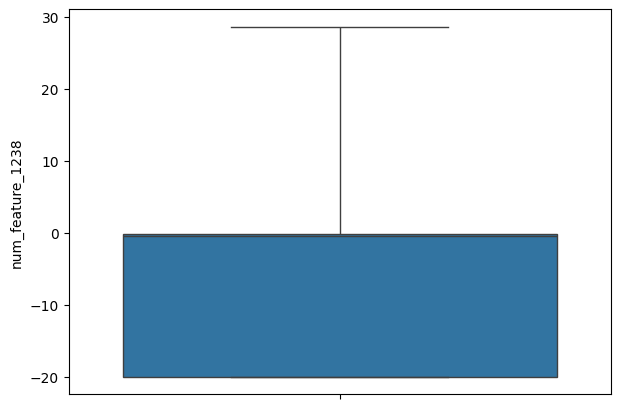

In [42]:
plt.figure(figsize=(7, 5))
sns.boxplot(train["num_feature_1238"])

<Axes: ylabel='num_feature_2238'>

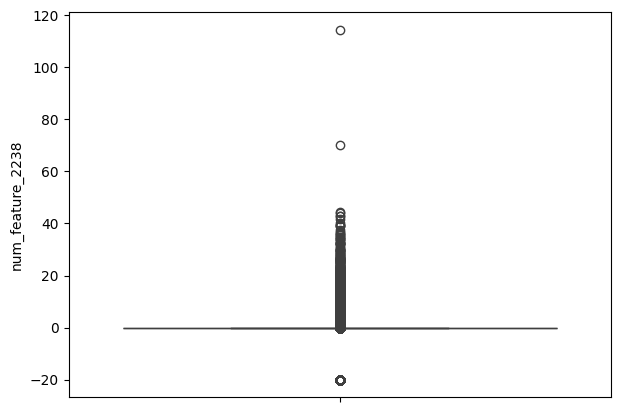

In [44]:
plt.figure(figsize=(7, 5))
sns.boxplot(train["num_feature_2238"])

<Axes: ylabel='num_feature_1238'>

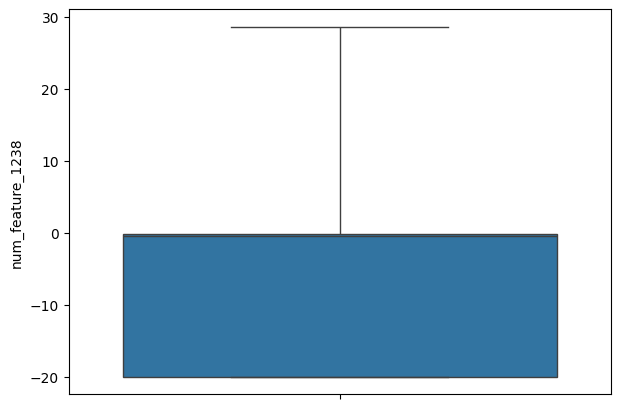

In [45]:
plt.figure(figsize=(7, 5))
sns.boxplot(train["num_feature_1238"])

<Axes: ylabel='num_feature_1286'>

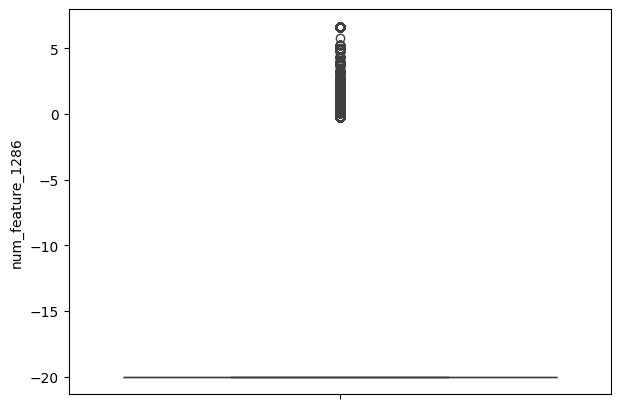

In [47]:
plt.figure(figsize=(7, 5))
sns.boxplot(train["num_feature_1286"])

<Axes: ylabel='num_feature_1486'>

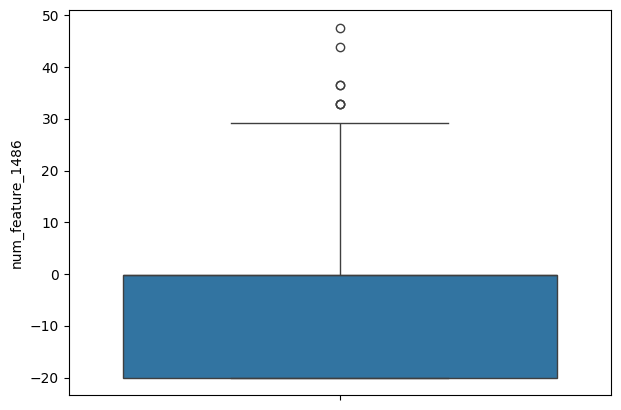

In [48]:
plt.figure(figsize=(7, 5))
sns.boxplot(train["num_feature_1486"])

В общем все конечно смещается из-за NaN значений, которые заполняются -20 на данный момент, возможно уже на другое число. Суть в том, что есть выбросы которые стоит обработать, выбросы которые я заметил именно в положительном диапозоне, так что я бы сделал только верхний квантиль небольшой и сейчас подумаю как все же с NaN лучше поступить

In [50]:
train["num_feature_2359"].quantile([0.95, 0.99, 0.999, 0.9995])

0.9500   -0.023246
0.9900   -0.023246
0.9990    3.477882
0.9995    6.979010
Name: num_feature_2359, dtype: float64

In [37]:
((train["num_feature_2359"] > -1) & (train["num_feature_2359"] < 1)).sum()

np.int64(587180)

# Обработка выбросов

In [25]:
for col in train.columns:
    q0_5 = train[col].quantile(0.0005)
    q99_5 = train[col].quantile(0.9995)

    train[col] = train[col].clip(q0_5, q99_5)

# Обучение

In [26]:
scores = []
for target in target_cols:
    train_y_ = train_y[target]
    val_y_ = val_y[target]
    score = loading_unloading_wrapper(Path(f"{path_save_model_with_extra_feature2}{target}.pkl"), study_model_all_feature, params, train_y_, val_y_, cat_cols)
    scores.append(score)

print(f"Macro_average: {sum(scores) / len(scores)}")

target_1_1
[100]	valid_0's auc: 0.904073
[200]	valid_0's auc: 0.903714
0.904419

target_1_2
[100]	valid_0's auc: 0.794403
0.797009

target_1_3
[100]	valid_0's auc: 0.868511
[200]	valid_0's auc: 0.870008
0.870115

target_1_4
[100]	valid_0's auc: 0.823234
[200]	valid_0's auc: 0.824965
0.825481

target_1_5
[100]	valid_0's auc: 0.8692
[200]	valid_0's auc: 0.872385
[300]	valid_0's auc: 0.870433
0.874966

target_2_1
[100]	valid_0's auc: 0.809571
0.811629

target_2_2
[100]	valid_0's auc: 0.934602
[200]	valid_0's auc: 0.935283
0.935412

target_2_3
[100]	valid_0's auc: 0.755623
0.768307

target_2_4
[100]	valid_0's auc: 0.719074
0.724401

target_2_5
[100]	valid_0's auc: 0.700888
[200]	valid_0's auc: 0.707962
[300]	valid_0's auc: 0.707659
0.710573

target_2_6
[100]	valid_0's auc: 0.710897
0.714257

target_2_7
[100]	valid_0's auc: 0.579961
[200]	valid_0's auc: 0.709911
[300]	valid_0's auc: 0.76923
[400]	valid_0's auc: 0.778943
0.780112

target_2_8
[100]	valid_0's auc: 0.496773
0.639993

target_3_1